<a href="https://colab.research.google.com/github/harshpaswanpro/Predictive-Maintenance---AI4I-2020-Faliure-Prediction/blob/main/Predictive_Maintenace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.6.1 2.2.3 2.1.3


Saving ai4i2020.csv to ai4i2020 (4).csv
(10000, 14)
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


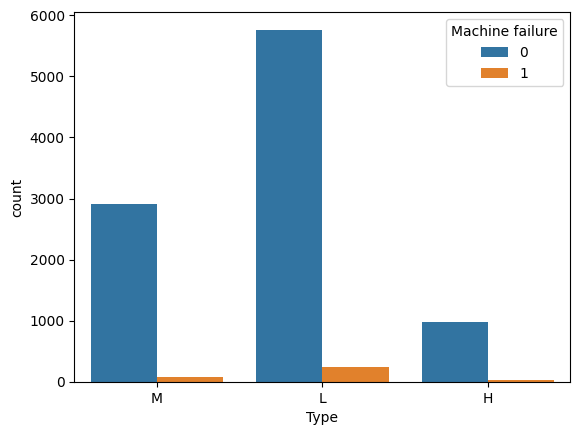

Precision: 0.9285714285714286
Recall: 0.5735294117647058
F1: 0.7090909090909091
ROC-AUC: 0.968529259529899
[[1929    3]
 [  29   39]]
Logistic Regression F1: 0.24347826086956523
Torque [Nm]                0.338108
Rotational speed [rpm]     0.277114
Tool wear [min]            0.209160
Air temperature [K]        0.098952
Process temperature [K]    0.062656
Type                       0.014010
dtype: float64
PR-AUC: 0.8118826050419233
0.5 P: 0.929 R: 0.574 F1: 0.709
0.4 P: 0.882 R: 0.662 F1: 0.756
0.3 P: 0.797 R: 0.75 F1: 0.773
0.25 P: 0.703 R: 0.765 F1: 0.732
0.2 P: 0.602 R: 0.779 F1: 0.679
0.5 0.9629629629629629 0.7647058823529411 0.8524590163934426
0.3 0.8888888888888888 0.8235294117647058 0.8549618320610687
0.2 0.76 0.8382352941176471 0.7972027972027972
precision 0.979 +/- 0.02
recall 0.797 +/- 0.031
f1 0.878 +/- 0.012
roc_auc 0.973 +/- 0.002
precision 0.916 +/- 0.044
recall 0.51 +/- 0.055
f1 0.652 +/- 0.038
roc_auc 0.964 +/- 0.01


In [22]:
import sklearn, pandas, numpy
print(sklearn.__version__, pandas.__version__, numpy.__version__)

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)
from google.colab import files
uploaded = files.upload()  # select ai4i2020.csv
df = pd.read_csv("ai4i2020.csv")
df.head()

print(df.shape)
print(df.dtypes)
print(df['Machine failure'].value_counts(normalize=True))

sns.countplot(x='Type', hue='Machine failure', data=df)
plt.show()

df = df.drop(columns=['UDI', 'Product ID'])  # these are just IDs, no predictive value
df['Type'] = df['Type'].map({'L':0, 'M':1, 'H':2})  # encode categorical

features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type']
X = df[features]
y = df['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Option A: class weighting (simplest, often good enough)
model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

# Option B: SMOTE oversampling (more involved — install imbalanced-learn)
# !pip install imbalanced-learn
# from imblearn.over_sampling import SMOTE
# X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train, y_train)

model.fit(X_train, y_train)
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print("Precision:", precision_score(y_test, pred))
print("Recall:", recall_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print(confusion_matrix(y_test, pred))

lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression F1:", f1_score(y_test, lr_pred))

importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, thr = precision_recall_curve(y_test, proba)
print("PR-AUC:", average_precision_score(y_test, proba))

for t in [0.5, 0.4, 0.3, 0.25, 0.2]:
    p = (proba >= t).astype(int)
    print(t, "P:", round(precision_score(y_test, p), 3),
             "R:", round(recall_score(y_test, p), 3),
             "F1:", round(f1_score(y_test, p), 3))

df2 = df.copy()
df2['Temp diff'] = df2['Process temperature [K]'] - df2['Air temperature [K]']
df2['Power'] = df2['Torque [Nm]'] * df2['Rotational speed [rpm]'] * 2*np.pi/60
df2['Wear x Torque'] = df2['Tool wear [min]'] * df2['Torque [Nm]']

features2 = features + ['Temp diff', 'Power', 'Wear x Torque']
X2 = df2[features2]
X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, stratify=y, random_state=42)

rf2 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf2.fit(X_train, y_train)
proba2 = rf2.predict_proba(X_test)[:, 1]
for t in [0.5, 0.3, 0.2]:
    p = (proba2 >= t).astype(int)
    print(t, precision_score(y_test, p), recall_score(y_test, p), f1_score(y_test, p))

from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(5, shuffle=True, random_state=42)
res = cross_validate(rf2, X2, y, cv=cv, scoring=['precision', 'recall', 'f1', 'roc_auc'])
for k in ['precision', 'recall', 'f1', 'roc_auc']:
    print(k, res[f'test_{k}'].mean().round(3), "+/-", res[f'test_{k}'].std().round(3))

rf_base = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
res_b = cross_validate(rf_base, df[features], y, cv=cv, scoring=['precision','recall','f1','roc_auc'])
for k in ['precision','recall','f1','roc_auc']:
    print(k, res_b[f'test_{k}'].mean().round(3), "+/-", res_b[f'test_{k}'].std().round(3))





